# Soil Moisture Regression

Data and model artifacts are intentionally external to this repository. Configure their locations in `.env` before running the notebook.


In [ ]:
# Reproducible project paths (launch Jupyter from the repository root)
import os
from pathlib import Path
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "README.md").is_file():
    PROJECT_ROOT = next(
        (parent for parent in PROJECT_ROOT.parents if (parent / "README.md").is_file()),
        PROJECT_ROOT,
    )

load_dotenv(PROJECT_ROOT / ".env")
DATA_ROOT = Path(os.getenv("SOIL_DATA_DIR", PROJECT_ROOT / "data")).expanduser()
MODEL_ROOT = Path(os.getenv("SOIL_MODEL_DIR", PROJECT_ROOT / "models")).expanduser()
OUTPUT_ROOT = Path(os.getenv("SOIL_OUTPUT_DIR", PROJECT_ROOT / "outputs")).expanduser()

if not DATA_ROOT.is_absolute():
    DATA_ROOT = PROJECT_ROOT / DATA_ROOT
if not MODEL_ROOT.is_absolute():
    MODEL_ROOT = PROJECT_ROOT / MODEL_ROOT
if not OUTPUT_ROOT.is_absolute():
    OUTPUT_ROOT = PROJECT_ROOT / OUTPUT_ROOT

MODEL_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / ".cache").mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / ".cache").mkdir(parents=True, exist_ok=True)


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import rasterio
import numpy as np
import os
from datetime import datetime

from torch.utils.data import random_split

import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import math
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torchvision.models as models
from torchvision.models.efficientnet import EfficientNet_V2_S_Weights
import torch.nn as nn
import cv2
import glob

In [3]:
# Load hourly CSV
csv_path = str(DATA_ROOT / "weather" / "Dair_Alla.csv")
df = pd.read_csv(csv_path, parse_dates=['date'])

# 2. Filter for daytime (06:00–18:00 UTC)
df = df[(df['date'].dt.hour >= 6) & (df['date'].dt.hour <= 18)]

# 3. Compute daily average soil moisture
df['date'] = df['date'].dt.date
daily_df = df.groupby('date')['soil_moisture_0_to_7cm'].mean().reset_index()

# 4. Collect all image paths and match to dates
image_records = []
base_dir = str(DATA_ROOT / "sentinel_downloads_1km")

for tile_folder in os.listdir(base_dir):
    tile_path = os.path.join(base_dir, tile_folder)
    if os.path.isdir(tile_path):
        for file in os.listdir(tile_path):
            if file.endswith(".tiff"):
                try:
                    date_str = file.replace(".tiff", "")
                    date_obj = datetime.strptime(date_str, "%Y-%m-%d").date()
                    full_path = os.path.join(tile_path, file)
                    image_records.append((date_obj, full_path))
                except:
                    continue

images_df = pd.DataFrame(image_records, columns=['date', 'path'])

# 5. Merge with soil moisture labels
merged_df = pd.merge(images_df, daily_df, on='date', how='inner')

# 6. Show or save result
final_df = merged_df[['path', 'soil_moisture_0_to_7cm']]
print(f" Matched image-label pairs: {len(final_df)}")


 Matched image-label pairs: 432


In [4]:
pd.set_option('display.max_colwidth', None)
final_df.head()

In [5]:
y_mean = final_df['soil_moisture_0_to_7cm'].mean()
y_std  = final_df['soil_moisture_0_to_7cm'].std()

print(f"y_mean = {y_mean:.6f}, y_std = {y_std:.6f}")

y_mean = 0.074219, y_std = 0.072210


In [6]:
image_path = str(DATA_ROOT / "sentinel_downloads_1km" / "tile_0" / "2024-01-10.tiff")

with rasterio.open(image_path) as src:
    print("Image shape (Height, Width):", src.height, src.width)
    print("Number of bands (Channels):", src.count)
    print("Data type:", src.dtypes[0])
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    image_array = src.read()

Image shape (Height, Width): 57 46
Number of bands (Channels): 2
Data type: float32
CRS: EPSG:4326
Bounds: BoundingBox(left=35.60446, bottom=32.19625, right=35.61446, top=32.20625)


In [7]:
# Parameters
IMG_SIZE  = 224
BATCH     = 32
N_EPOCHS  = 200
LR        = 1e-4
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. Data Normalization

y_mean = final_df['soil_moisture_0_to_7cm'].mean()
y_std  = final_df['soil_moisture_0_to_7cm'].std()
final_df['y_std'] = (final_df['soil_moisture_0_to_7cm'] - y_mean) / y_std

# 2. TIFF Preprocessing
def preprocess_tiff(path, size=224):
    with rasterio.open(path) as src:
        img = src.read()  # (2, H, W)
    img = np.array([(b - b.min()) / (b.max() - b.min() + 1e-6) for b in img])
    img_resized = np.array([
        cv2.resize(band, (size, size), interpolation=cv2.INTER_LINEAR)
        for band in img
    ], dtype=np.float32)
    return torch.from_numpy(img_resized)

In [8]:
from torch.utils.data import Dataset, DataLoader, random_split

class MoistureDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = preprocess_tiff(row["path"], IMG_SIZE)
        label = torch.tensor(row["y_std"], dtype=torch.float32)  # <- for regression
        return img, label

# Create dataset
full_ds = MoistureDataset(final_df)

# Split
train_ds, val_ds, test_ds = random_split(
    full_ds, [0.7, 0.15, 0.15], generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [9]:
# 4. Model Setup (EfficientNetV2 for 2-Band Regression)

model = models.efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
original_conv = model.features[0][0]
model.features[0][0] = nn.Conv2d(
    in_channels=2,
    out_channels=original_conv.out_channels,
    kernel_size=original_conv.kernel_size,
    stride=original_conv.stride,
    padding=original_conv.padding,
    bias=original_conv.bias is not None
)
with torch.no_grad():
    model.features[0][0].weight[:] = original_conv.weight[:, :2]
n_in = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.5, True),
    nn.Linear(n_in, 1)
)
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:00<00:00, 166MB/s] 


In [10]:
# Optimizer and loss
opt = torch.optim.AdamW(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

# Metric function
def epoch_metrics(preds, truths):
    mse  = mean_squared_error(truths, preds)
    mae  = mean_absolute_error(truths, preds)
    rmse = math.sqrt(mse)
    return mse, mae, rmse

# Early stopping setup
best_mae = float('inf')
patience = 20
patience_counter = 0
best_model_path = str(MODEL_ROOT / "regression.pth")

for epoch in range(1, N_EPOCHS + 1):
    # ─ Train ─
    model.train()
    for x, y in train_dl:
        x, y = x.to(DEVICE), y.unsqueeze(1).to(DEVICE)
        pred = model(x)
        loss = loss_fn(pred, y)
        opt.zero_grad(); loss.backward(); opt.step()

    # ─ Validation ─
    model.eval(); v_preds, v_truths = [], []
    with torch.no_grad():
        for x, y in val_dl:
            x = x.to(DEVICE)
            preds = model(x).cpu().squeeze().tolist()
            v_preds.extend(preds if isinstance(preds, list) else [preds])
            v_truths.extend(y.tolist())

    v_preds = np.array(v_preds)
    v_truths = np.array(v_truths)
    mse, mae, rmse = epoch_metrics(v_preds, v_truths)
    print(f"Epoch {epoch:02d} | Val MSE: {mse:.4f}  MAE: {mae:.4f}  RMSE: {rmse:.4f}")

    # ─ Early stopping logic ─
    if mae < best_mae:
        best_mae = mae
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  New best MAE: {mae:.4f} — model saved")
    else:
        patience_counter += 1
        print(f"  No improvement in MAE for {patience_counter} epoch(s)")

        if patience_counter >= patience:
            print(f"\n Early stopping triggered — best MAE: {best_mae:.4f}")
            break

Epoch 01 | Val MSE: 0.6084  MAE: 0.6261  RMSE: 0.7800
  New best MAE: 0.6261 — model saved
Epoch 02 | Val MSE: 0.5200  MAE: 0.5977  RMSE: 0.7211
  New best MAE: 0.5977 — model saved
Epoch 03 | Val MSE: 0.3199  MAE: 0.4497  RMSE: 0.5656
  New best MAE: 0.4497 — model saved
Epoch 04 | Val MSE: 0.2652  MAE: 0.3717  RMSE: 0.5150
  New best MAE: 0.3717 — model saved
Epoch 05 | Val MSE: 0.1799  MAE: 0.3160  RMSE: 0.4241
  New best MAE: 0.3160 — model saved
Epoch 06 | Val MSE: 0.1678  MAE: 0.3045  RMSE: 0.4096
  New best MAE: 0.3045 — model saved
Epoch 07 | Val MSE: 0.1374  MAE: 0.2778  RMSE: 0.3707
  New best MAE: 0.2778 — model saved
Epoch 08 | Val MSE: 0.1432  MAE: 0.2827  RMSE: 0.3784
  No improvement in MAE for 1 epoch(s)
Epoch 09 | Val MSE: 0.1427  MAE: 0.2643  RMSE: 0.3778
  New best MAE: 0.2643 — model saved
Epoch 10 | Val MSE: 0.1425  MAE: 0.2552  RMSE: 0.3775
  New best MAE: 0.2552 — model saved
Epoch 11 | Val MSE: 0.1191  MAE: 0.2424  RMSE: 0.3451
  New best MAE: 0.2424 — model sav

In [17]:
model.eval()
test_preds, test_truths = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(DEVICE)
        preds = model(x).cpu().squeeze().tolist()
        y = y.squeeze().tolist()

        # Ensure both are lists
        if isinstance(preds, float): preds = [preds]
        if isinstance(y, float):     y = [y]

        test_preds.extend(preds)
        test_truths.extend(y)

# Convert from standardized back to original scale
test_preds_real  = np.array(test_preds)  * y_std + y_mean
test_truths_real = np.array(test_truths) * y_std + y_mean

# Calculate metrics
mse, mae, rmse = epoch_metrics(test_preds_real, test_truths_real)
print(f"\n TEST SET METRICS:")
print(f"   MSE :  {mse:.4f}")
print(f"   MAE :  {mae:.4f}")
print(f"   RMSE:  {rmse:.4f}")

# Create results DataFrame using correct test paths
test_paths = [final_df.iloc[i]['path'] for i in test_ds.indices]

results_df = pd.DataFrame({
    'path': test_paths,
    'label': test_preds_real,
    'truth': test_truths_real
})

# Optional: Add error column
results_df['abs_error'] = np.abs(results_df['label'] - results_df['truth'])

# Show results
print("\n Sample Predictions:")
display(results_df.head())


 TEST SET METRICS:
   MSE :  0.0011
   MAE :  0.0187
   RMSE:  0.0326

 Sample Predictions:


,path,label,truth,abs_error
0,/sentinel_downloads_1km/tile_1/2024-08-02.tiff,0.033307,0.026000,0.007307
1,/sentinel_downloads_1km/tile_4/2024-07-03.tiff,0.016783,0.020000,0.003217
2,/sentinel_downloads_1km/tile_7/2024-12-15.tiff,0.108921,0.071615,0.037305
3,/sentinel_downloads_1km/tile_1/2024-12-15.tiff,0.114206,0.071615,0.042591
4,/sentinel_downloads_1km/tile_5/2024-09-06.tiff,0.022618,0.025231,0.002613


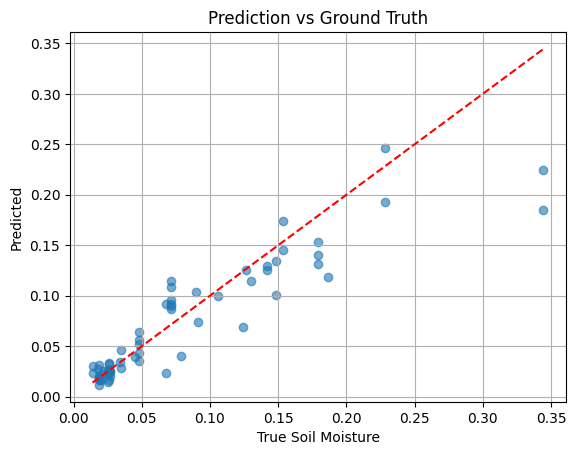

In [18]:
# 7. Scatter Plot

plt.scatter(results_df["truth"], results_df["label"], alpha=0.6)
plt.plot([min(results_df["truth"]), max(results_df["truth"])],
         [min(results_df["truth"]), max(results_df["truth"])], 'r--')
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted")
plt.title("Prediction vs Ground Truth")
plt.grid(True)
plt.show()

In [19]:
# 8. Predict Single Image

def predict_image(path):
    model.eval()
    x = preprocess_tiff(path, IMG_SIZE).unsqueeze(0).to(DEVICE)  # shape: (1,2,224,224)
    with torch.no_grad():
        pred = model(x).cpu().item()
    return pred * y_std + y_mean

# Example:
# moisture = predict_image(str(DATA_ROOT / "sample.tiff"))
# print("Predicted soil moisture:", moisture)

In [21]:
# Input folder
input_dir = str(DATA_ROOT / "testing" / "regression")
output_dir = str(OUTPUT_ROOT / "regression_merged")
os.makedirs(output_dir, exist_ok=True)

# Collect all files
all_files = glob.glob(os.path.join(input_dir, '*.tiff'))

# Group by date
from collections import defaultdict
grouped = defaultdict(dict)

for file in all_files:
    if 'B8A' in file:
        date = os.path.basename(file).split('_')[0]
        grouped[date]['B8A'] = file
    elif 'B11' in file:
        date = os.path.basename(file).split('_')[0]
        grouped[date]['B11'] = file

# Merge B8A and B11 → Predict
predictions = []

for date, bands in grouped.items():
    if 'B8A' in bands and 'B11' in bands:
        with rasterio.open(bands['B8A']) as src_b8a:
            b8a = src_b8a.read(1)
            profile = src_b8a.profile

        with rasterio.open(bands['B11']) as src_b11:
            b11 = src_b11.read(1)

        # Stack (2, H, W)
        stacked = np.stack([b8a, b11])
        profile.update(count=2)

        # Save merged
        merged_path = os.path.join(output_dir, f"{date}_merged.tif")
        with rasterio.open(merged_path, 'w', **profile) as dst:
            dst.write(stacked)

        # Predict using model
        moisture = predict_image(merged_path)
        predictions.append((date, moisture))

        print(f"{date}: Soil Moisture = {moisture:.5f}")

    else:
        print(f" Skipping {date} — missing B8A or B11")

# Convert to DataFrame (optional)
import pandas as pd
results_df = pd.DataFrame(predictions, columns=['date', 'predicted_soil_moisture'])
print("\n Final Predictions:")
results_df.head(20)

2025-06-28-00: Soil Moisture = 0.08813
2025-01-14-00: Soil Moisture = 0.13480
2025-01-19-00: Soil Moisture = 0.14002
2025-06-20-00: Soil Moisture = 0.08879
2025-01-09-00: Soil Moisture = 0.14889
2025-06-18-00: Soil Moisture = 0.10396

 Final Predictions:


,date,predicted_soil_moisture
0,2025-06-28-00,0.088129
1,2025-01-14-00,0.134796
2,2025-01-19-00,0.140022
3,2025-06-20-00,0.088788
4,2025-01-09-00,0.148893
5,2025-06-18-00,0.103964


 Showing: 2025-01-09-00_merged.tif


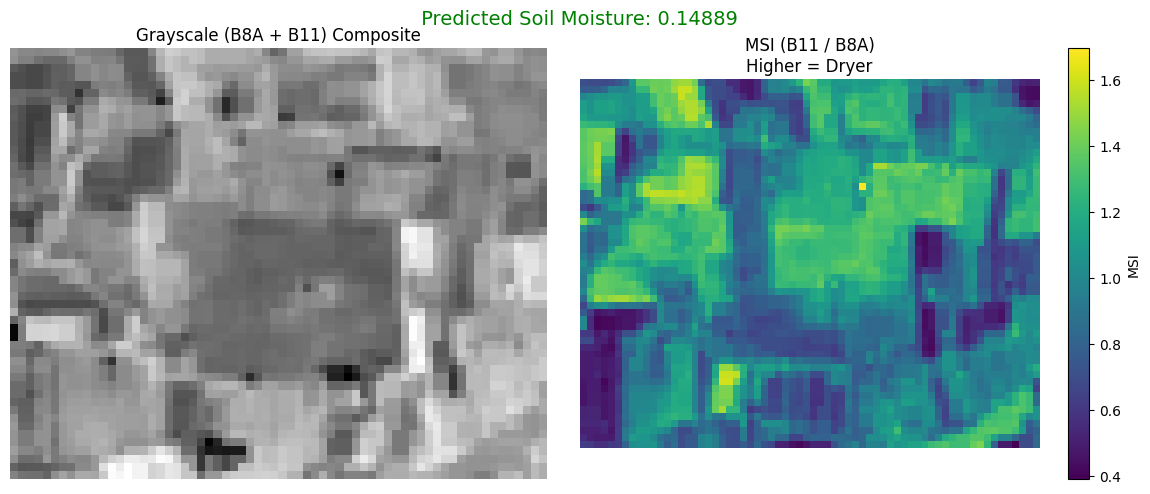

 Showing: 2025-01-14-00_merged.tif


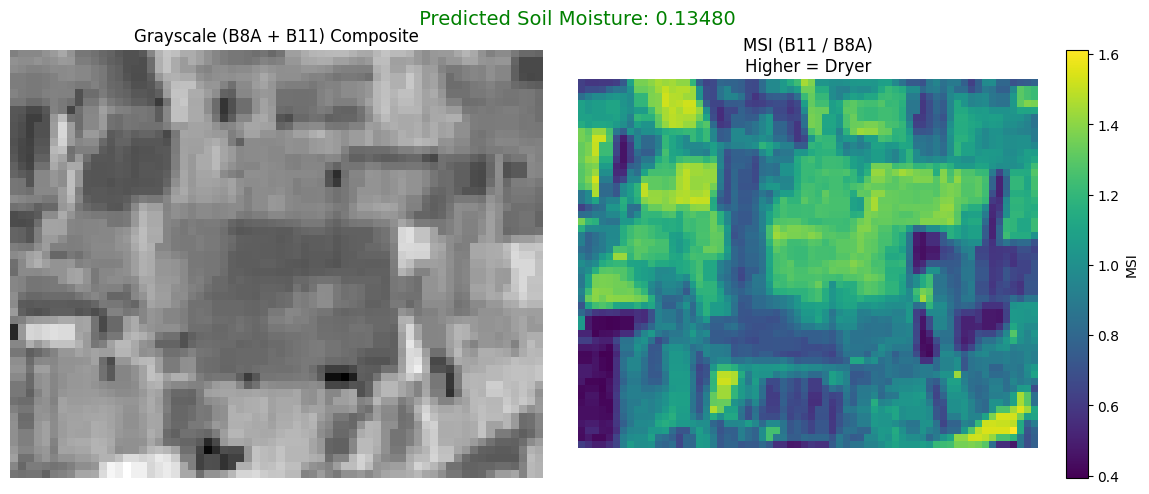

 Showing: 2025-01-19-00_merged.tif


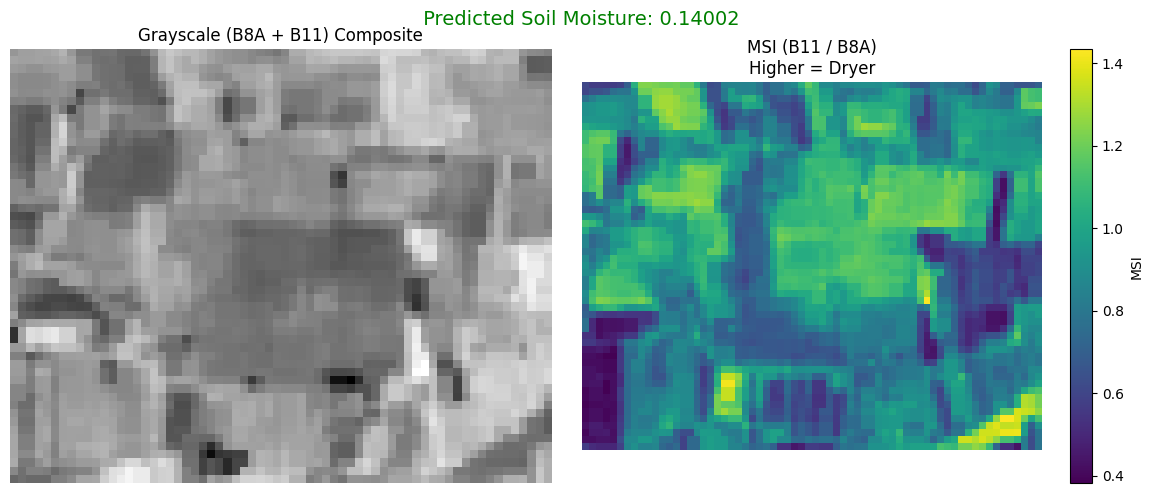

 Showing: 2025-06-18-00_merged.tif


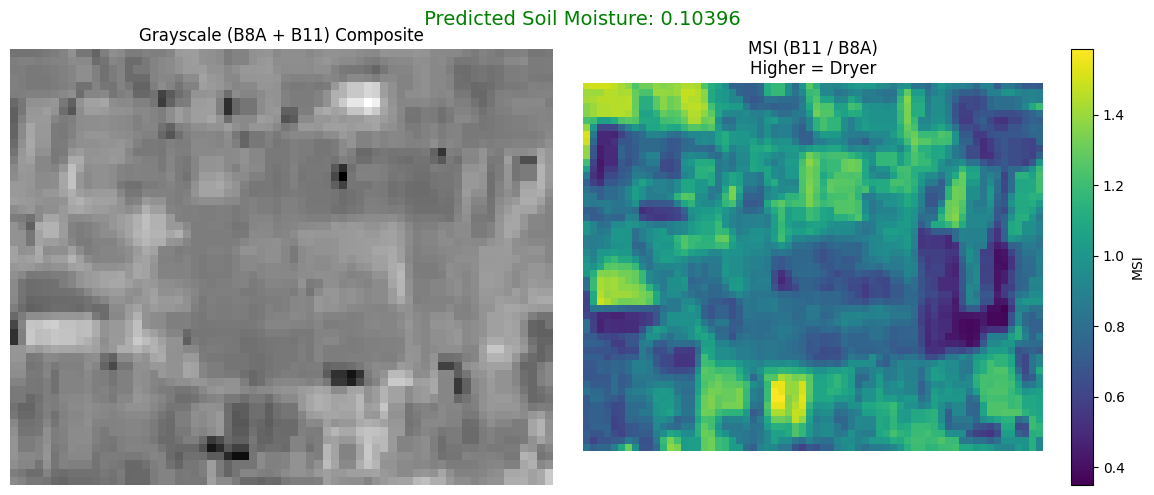

 Showing: 2025-06-20-00_merged.tif


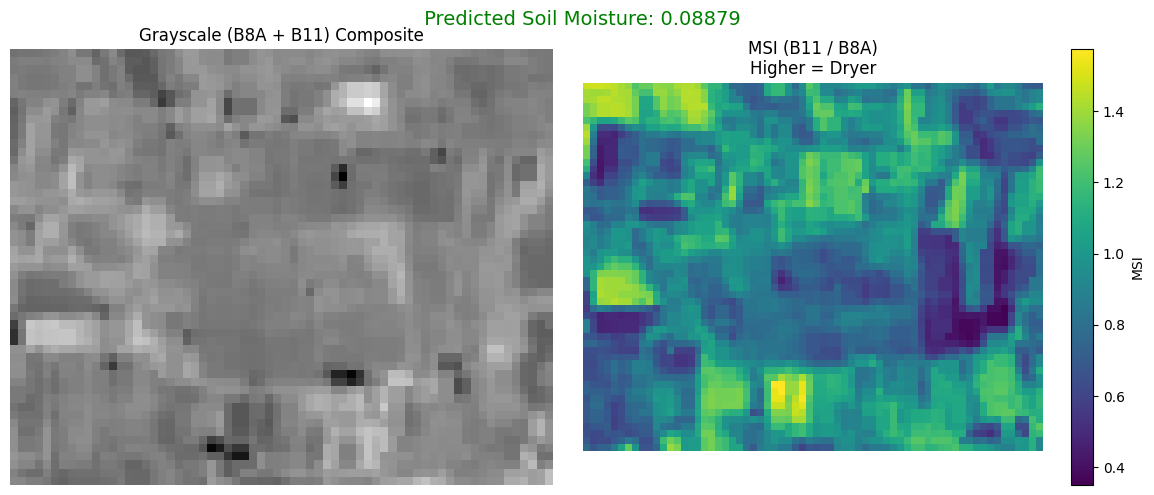

 Showing: 2025-06-28-00_merged.tif


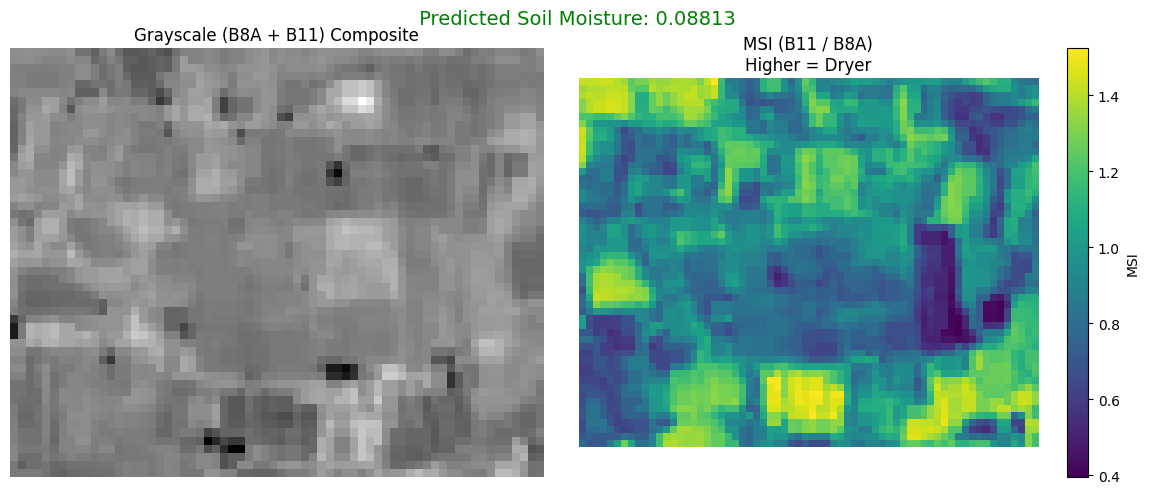

In [22]:
# Folder containing merged 2-band TIFFs
image_dir = str(OUTPUT_ROOT / "regression_merged")
tiff_files = sorted(glob.glob(os.path.join(image_dir, '*.tif')))

def visualize_with_prediction_and_msi(image_path):
    # Load image
    with rasterio.open(image_path) as src:
        img = src.read()  # (2, H, W)
        b8a = img[0]
        b11 = img[1]
    
    # Predict soil moisture
    moisture = predict_image(image_path)

    # Composite grayscale (mean of bands)
    composite = (b8a + b11) / 2

    # Moisture Stress Index (MSI = B11 / B8A)
    msi = b11 / (b8a + 1e-6)
    msi = np.clip(msi, 0, 10)  # Limit extreme values

    # Plot side-by-side
    plt.figure(figsize=(12, 5))

    # Left: grayscale composite
    plt.subplot(1, 2, 1)
    plt.imshow(composite, cmap='gray')
    plt.title("Grayscale (B8A + B11) Composite")
    plt.axis('off')

    # Right: MSI overlay
    plt.subplot(1, 2, 2)
    plt.imshow(msi, cmap='viridis')
    plt.title("MSI (B11 / B8A)\nHigher = Dryer")
    plt.axis('off')
    plt.colorbar(label='MSI')

    # Overall title
    plt.suptitle(f" Predicted Soil Moisture: {moisture:.5f}", fontsize=14, color='green')
    plt.tight_layout()
    plt.show()

# Loop through and show each image
for path in tiff_files:
    print(f" Showing: {os.path.basename(path)}")
    visualize_with_prediction_and_msi(path)